<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Emergence_Simulator_for_Multi_Agent_Scientific_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emergence Simulator for Multi-Agent Scientific Systems

This notebook implements a simulation of agents exchanging information and solving scientific problems collectively, inspired by DARPA DICE and collective intelligence research.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict
import random

print("Libraries imported successfully.")

Libraries imported successfully.


## Core Framework

We define the `ScientistAgent` which carries specific knowledge (vectors) and the `Environment` that facilitates diffusion.

In [2]:
class ScientistAgent:
    def __init__(self, agent_id: int, knowledge_dim: int = 10):
        self.agent_id = agent_id
        # Initialize knowledge as a random vector
        self.knowledge = np.random.rand(knowledge_dim)
        self.collaboration_history = []

    def interact(self, other_agent: 'ScientistAgent'):
        # Knowledge diffusion logic: agents move closer in knowledge space
        learning_rate = 0.1
        diff = other_agent.knowledge - self.knowledge
        self.knowledge += learning_rate * diff
        self.collaboration_history.append(other_agent.agent_id)

class SimulationEnvironment:
    def __init__(self, num_agents: int, knowledge_dim: int = 10):
        self.agents = [ScientistAgent(i, knowledge_dim) for i in range(num_agents)]
        self.network = nx.complete_graph(num_agents) # Start with potential for all to meet

    def step(self):
        # Randomly pair agents to simulate research interactions
        pairs = list(range(len(self.agents)))
        random.shuffle(pairs)
        for i in range(0, len(pairs)-1, 2):
            a1, a2 = self.agents[pairs[i]], self.agents[pairs[i+1]]
            a1.interact(a2)
            a2.interact(a1)

# Initialize a small-scale test
sim = SimulationEnvironment(num_agents=50)
print(f"Simulation initialized with {len(sim.agents)} agents.")

Simulation initialized with 50 agents.


## Running the Simulation and Visualizing Diffusion

We will run the simulation for 100 steps and use PCA to observe how the agents' knowledge states evolve.

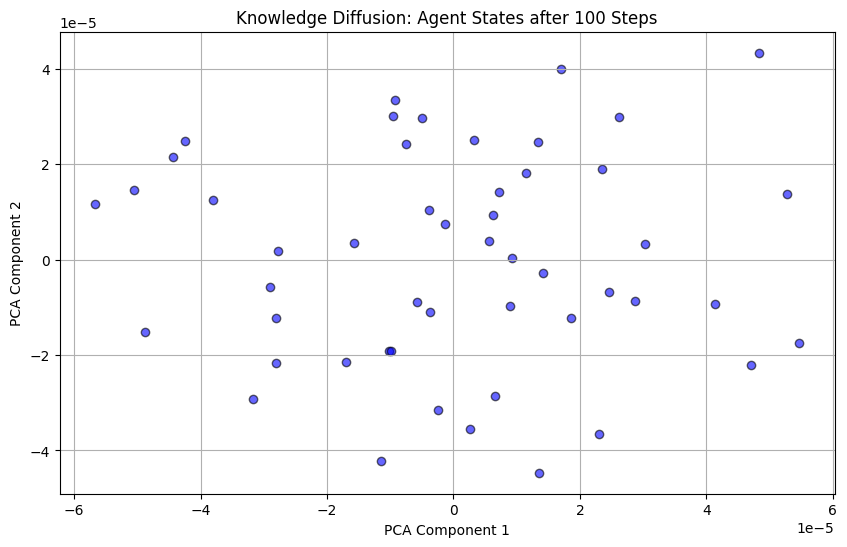

In [3]:
from sklearn.decomposition import PCA

# Run simulation for 100 steps
for _ in range(100):
    sim.step()

# Extract knowledge vectors
knowledge_data = np.array([agent.knowledge for agent in sim.agents])

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
reduced_knowledge = pca.fit_transform(knowledge_data)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(reduced_knowledge[:, 0], reduced_knowledge[:, 1], alpha=0.6, c='blue', edgecolors='k')
plt.title("Knowledge Diffusion: Agent States after 100 Steps")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

## Identifying Emergent Clusters

To identify self-organizing research teams, we apply K-Means clustering to the final knowledge states.

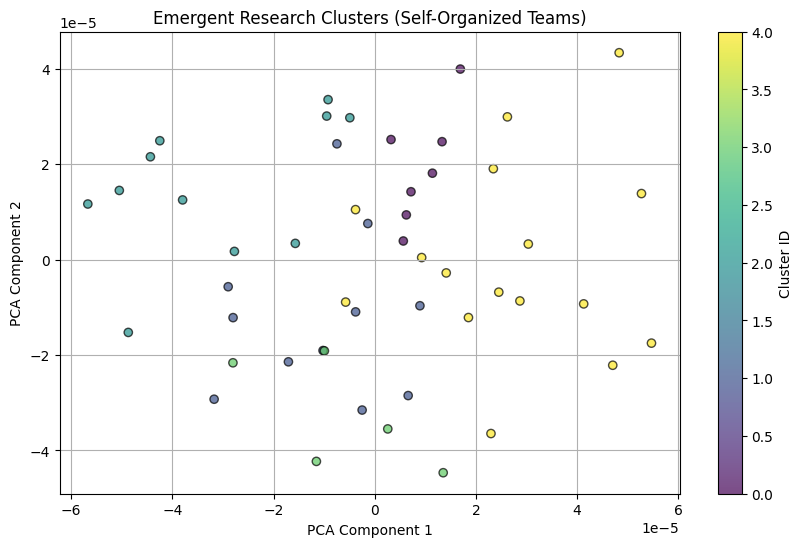

Identified 5 emergent clusters among 50 agents.


In [4]:
from sklearn.cluster import KMeans

# Assuming 5 potential research domains/clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(knowledge_data)
labels = kmeans.labels_

# Visualize with cluster labels
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_knowledge[:, 0], reduced_knowledge[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Cluster ID')
plt.title("Emergent Research Clusters (Self-Organized Teams)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

print(f"Identified {n_clusters} emergent clusters among {len(sim.agents)} agents.")

## Visualizing the Collaboration Network

Finally, we visualize the agents as a network. Edges represent that agents have interacted, and colors represent the emergent research teams (clusters) they've formed.

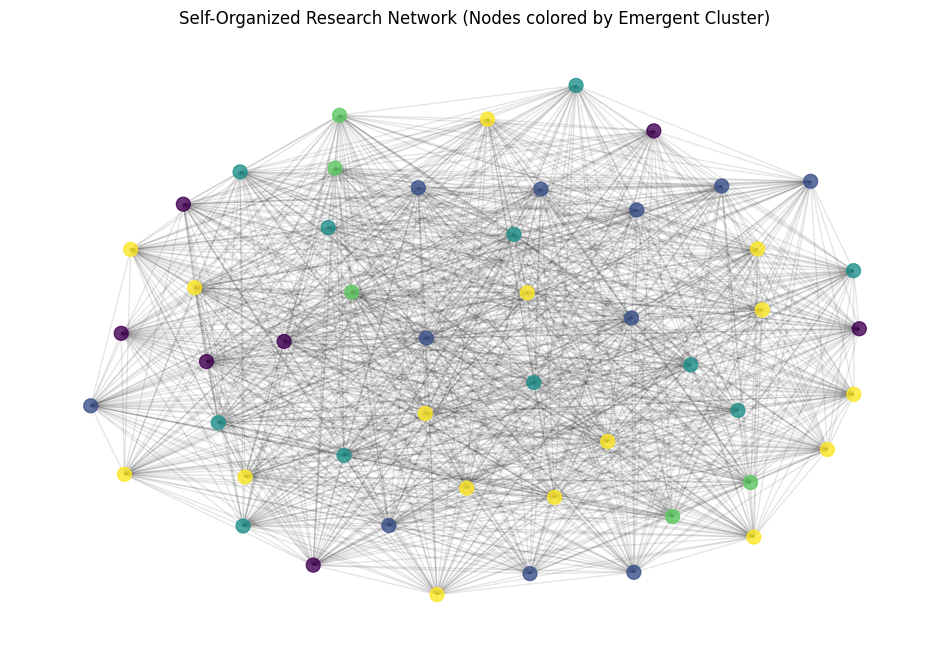

In [6]:
import networkx as nx

# Create a graph for visualization
G = nx.Graph()

# Add nodes with cluster labels
for i, label in enumerate(labels):
    G.add_node(i, cluster=label)

# Add edges based on collaboration history
for agent in sim.agents:
    for colleague_id in set(agent.collaboration_history):
        G.add_edge(agent.agent_id, colleague_id)

# Draw the network
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(G, pos, node_size=100, node_color=labels, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title("Self-Organized Research Network (Nodes colored by Emergent Cluster)")
plt.axis('off')
plt.show()

## Visualizing the Collaboration Network

Finally, we visualize the agents as a network. Edges represent that agents have interacted, and colors represent the emergent research teams (clusters) they've formed.

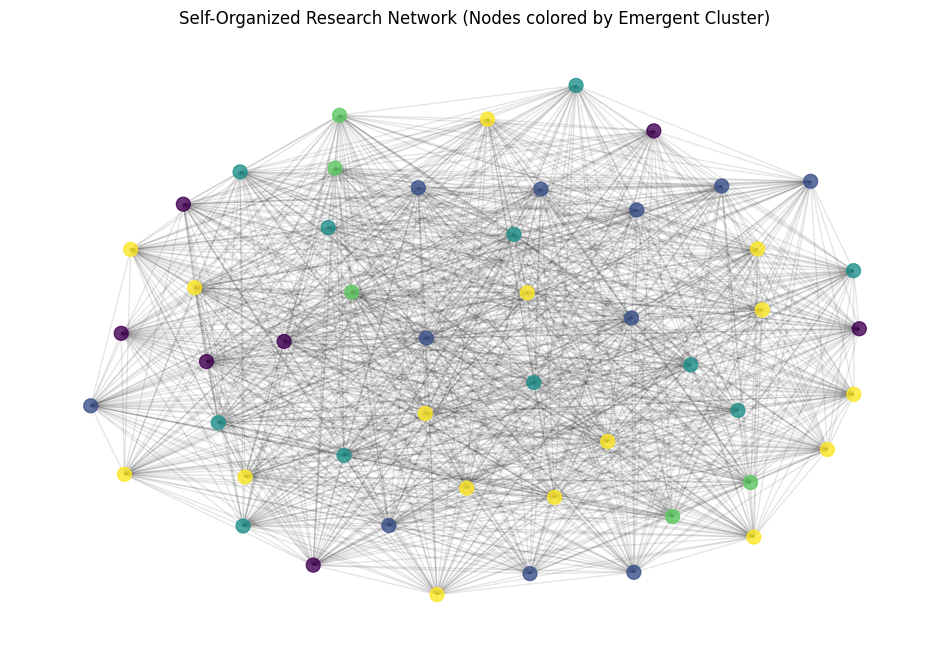

In [5]:
import networkx as nx

# Create a graph for visualization
G = nx.Graph()

# Add nodes with cluster labels
for i, label in enumerate(labels):
    G.add_node(i, cluster=label)

# Add edges based on collaboration history (showing connections formed during simulation)
for agent in sim.agents:
    for colleague_id in set(agent.collaboration_history):
        G.add_edge(agent.agent_id, colleague_id)

# Draw the network
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(G, pos, node_size=100, node_color=labels, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title("Self-Organized Research Network (Nodes colored by Emergent Cluster)")
plt.axis('off')
plt.show()